# 1. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.data import download_prices
from src.clustering import (
    compute_clusters,
    find_correlated_pairs
)
from src.cointegration import (
    test_cointegration,
    select_best_pairs
)
from src.pairs_trading import (
    generate_trading_signals,
    run_simple_backtest,
    compute_performance_metrics
)

from src.visualization import (
    plot_best_pair,
    plot_clusters_pca,
    plot_dendrogram,
    plot_spread,
    plot_zscore,
    plot_cumulative_return,
    plot_lstm_training_history,
    plot_lstm_predictions,
    plot_benchmark_comparison,
    plot_ml_filtered_strategy,
    plot_regression_predictions,
    plot_lstm_regression_predictions
)

from src.ml_models import train_classifier

from src.sentiment import compute_sentiment
from src.aggregation import build_final_recommendation

from src.pairs_trading import optimize_thresholds
from src.visualization import (
    plot_optimized_backtest,
    plot_optimized_zscore
)

from src.benchmark import (
    build_benchmark_df,
    compute_strategy_performance,
    apply_ml_filter,
    compute_ml_filtered_performance
)


from src.ml_models import train_regressor


from src.reporting import build_summary_results

from src.meta_model import (
    train_meta_model,
    build_final_decision_table
)

from src.transaction_costs import (
    TransactionCostModel,
    apply_costs_to_backtest,
    compute_breakeven_cost,
    cost_sensitivity_analysis
)

from statsmodels.tsa.stattools import coint

from src.stationarity_tests import test_spread_stationarity, adf_rolling

from src.ml_models import train_xgboost_classifier

from src.deep_learning import (
    train_lstm_classifier,
    train_lstm_regressor
)


# 2. Etude des données

In [2]:
prices, returns = download_prices(
    TICKERS,
    START_DATE,
    END_DATE
)

prices.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,177.939728,196.799469,170.404495,159.118942,207.860001,191.345474,251.763718,55.497559,99.587166,153.153336,...,322.462280,153.479980,30.061140,145.227341,325.363251,143.532486,465.858124,213.970413,39.341389,45.584694
2022-01-04,175.681412,197.797852,167.522003,164.227081,213.630005,201.587570,244.638306,54.136402,101.399223,152.147034,...,316.933044,155.083130,29.231791,145.735489,322.101196,146.527557,455.303436,214.965729,40.114120,44.749573
2022-01-05,171.008286,195.453827,164.356995,162.477081,213.070007,203.131210,224.375793,53.279053,102.058891,151.619461,...,304.766663,151.224411,27.549143,146.395233,322.705597,147.237137,454.181091,212.588608,40.526733,45.354633
2022-01-06,168.153625,195.479904,163.253998,163.965988,211.339996,205.201889,225.834381,53.844734,102.927345,153.290100,...,302.358429,150.096680,28.122000,145.164932,320.028778,149.596298,435.594208,212.347046,40.331684,45.228580
2022-01-07,168.319748,197.320328,162.554001,165.369507,215.500000,207.235504,225.006531,54.030354,104.405373,154.198730,...,302.512543,146.303207,27.192854,145.084686,310.108276,153.199585,425.345551,209.651016,41.182053,45.660313


In [3]:
returns.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.012691,0.005073,-0.016916,0.032103,0.027759,0.053527,-0.028302,-0.024526,0.018196,-0.006571,...,-0.017147,0.010445,-0.027589,0.003499,-0.010026,0.020867,-0.022656,0.004652,0.019642,-0.018320
2022-01-05,-0.026600,-0.011851,-0.018893,-0.010656,-0.002621,0.007657,-0.082826,-0.015837,0.006506,-0.003468,...,-0.038388,-0.024882,-0.057562,0.004527,0.001876,0.004843,-0.002465,-0.011058,0.010286,0.013521
2022-01-06,-0.016693,0.000133,-0.006711,0.009164,-0.008119,0.010194,0.006501,0.010617,0.008509,0.011019,...,-0.007902,-0.007457,0.020794,-0.008404,-0.008295,0.016023,-0.040924,-0.001136,-0.004813,-0.002779
2022-01-07,0.000988,0.009415,-0.004288,0.008560,0.019684,0.009910,-0.003666,0.003447,0.014360,0.005928,...,0.000510,-0.025274,-0.033040,-0.000553,-0.030999,0.024087,-0.023528,-0.012696,0.021084,0.009546
2022-01-10,0.000116,0.013551,-0.006570,-0.003670,-0.028724,-0.011375,0.005782,0.011287,0.000640,-0.007793,...,0.000732,-0.041600,0.005615,-0.013641,0.000247,-0.013113,0.013955,-0.023000,-0.006822,-0.001932


In [4]:
returns.describe()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
count,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,...,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000
mean,0.000591,0.000415,0.000627,0.000974,0.000058,0.000998,0.000660,0.000145,0.000545,-0.000256,...,0.000491,-0.000741,0.002588,0.000198,0.000195,0.000762,0.000185,0.000601,-0.000011,0.000977
std,0.017067,0.014391,0.024147,0.018265,0.023276,0.018614,0.024194,0.014538,0.016233,0.019071,...,0.017372,0.021639,0.034817,0.011080,0.017601,0.014106,0.015374,0.013994,0.014037,0.012994
min,-0.058680,-0.071378,-0.140494,-0.084713,-0.104701,-0.070203,-0.197371,-0.137304,-0.067205,-0.131632,...,-0.077156,-0.199809,-0.100046,-0.062323,-0.089158,-0.077607,-0.081120,-0.054915,-0.074978,-0.113757
25%,-0.008437,-0.007020,-0.012626,-0.008823,-0.011514,-0.009038,-0.011703,-0.006887,-0.008050,-0.009892,...,-0.008516,-0.011106,-0.018588,-0.005744,-0.009277,-0.006741,-0.007420,-0.007124,-0.006825,-0.005267
50%,0.001117,-0.000187,0.000331,0.000740,0.000447,0.001114,0.000622,0.000293,0.001021,-0.000148,...,0.000789,-0.000185,0.003270,0.000476,-0.000041,0.001340,0.000668,0.001326,0.000256,0.001105
75%,0.009751,0.007844,0.014102,0.011185,0.012969,0.010895,0.013243,0.007306,0.009501,0.009671,...,0.010602,0.010267,0.022030,0.006558,0.009633,0.007873,0.008166,0.007303,0.007077,0.007683
max,0.088975,0.118179,0.135359,0.105401,0.094630,0.088547,0.114969,0.068002,0.089035,0.114989,...,0.082268,0.121791,0.243696,0.042699,0.094146,0.090019,0.072407,0.105991,0.092705,0.069865


## 2. 1. Clustering

In [5]:
cluster_df, corr_matrix, linkage_matrix = compute_clusters(
    returns,
    DISTANCE_THRESHOLD
)

cluster_df

,Ticker,Cluster
14,JNJ,1
1,AMGN,1
26,UNH,1
23,PG,1
19,MRK,1
17,MCD,1
16,KO,1
29,WMT,2
28,VZ,3
8,CVX,4


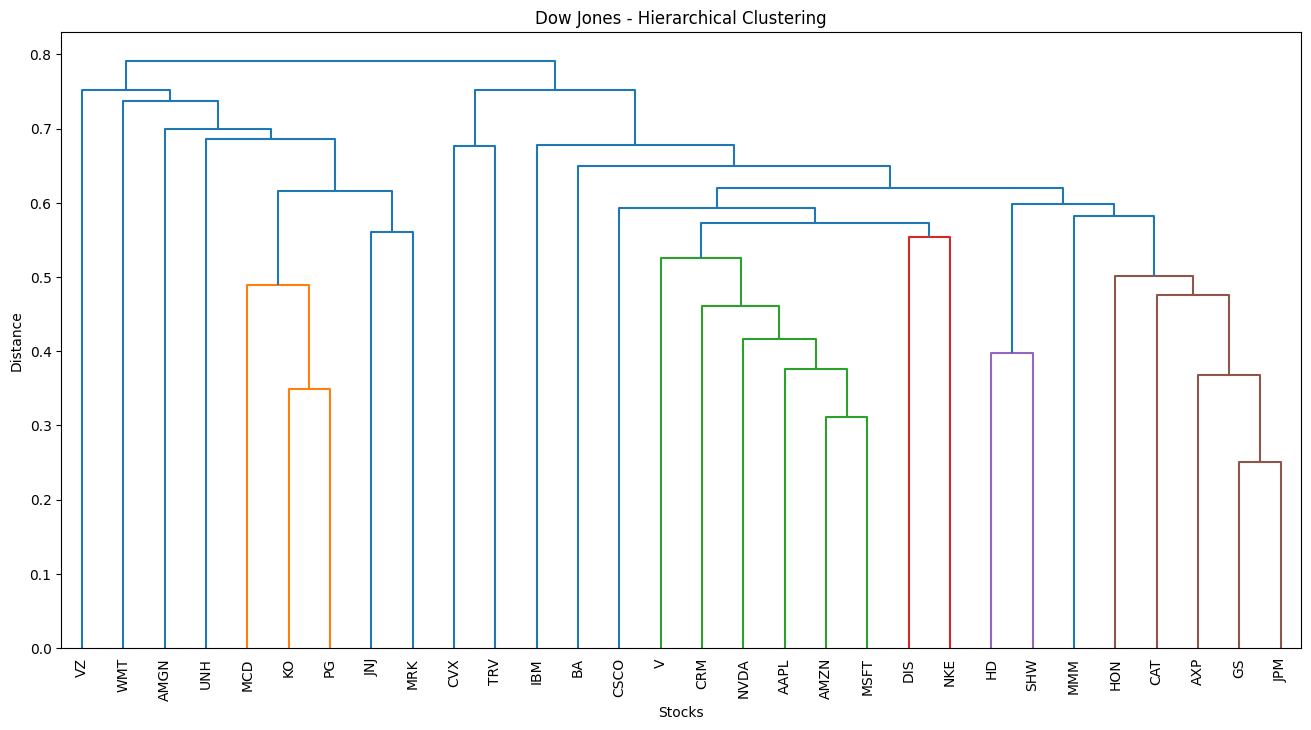

In [6]:
plot_dendrogram(
    linkage_matrix,
    labels=returns.columns
)

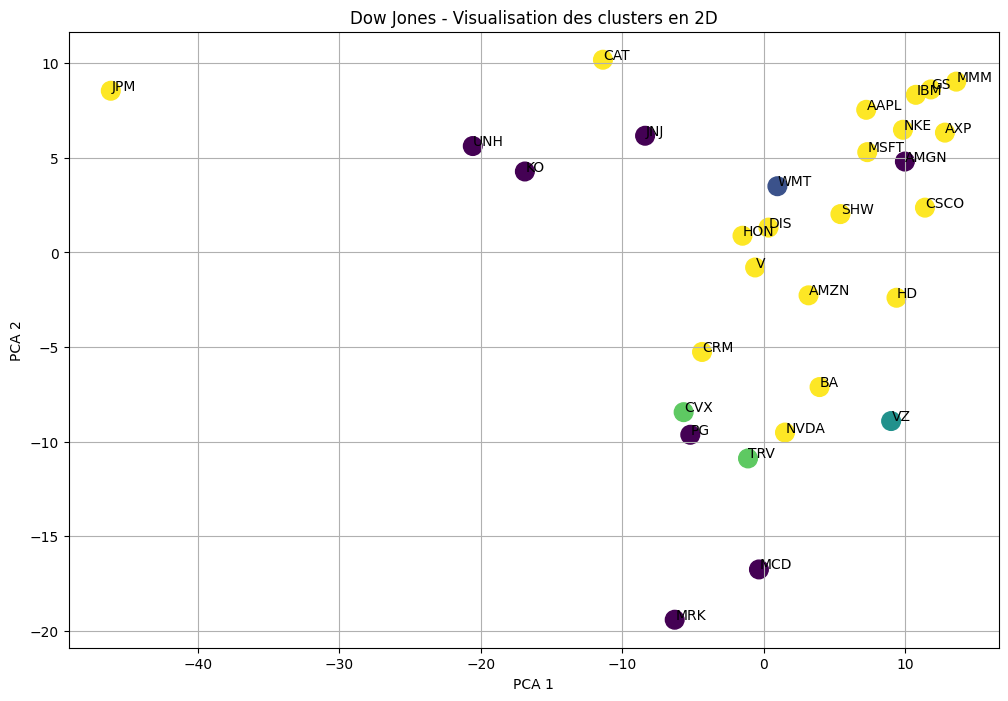

,Ticker,Cluster,PCA_1,PCA_2
14,JNJ,1,-8.389495,6.170822
1,AMGN,1,9.975453,4.806990
26,UNH,1,-20.568333,5.626678
23,PG,1,-5.195049,-9.635511
19,MRK,1,-6.295192,-19.413142


In [7]:
cluster_pca_df = plot_clusters_pca(
    returns,
    cluster_df
)

cluster_pca_df.head()

In [8]:
for cluster in sorted(cluster_df["Cluster"].unique()):

    stocks = cluster_df[
        cluster_df["Cluster"] == cluster
    ]["Ticker"].tolist()

    print(f"\nCluster {cluster}:")
    print(stocks)


Cluster 1:
['JNJ', 'AMGN', 'UNH', 'PG', 'MRK', 'MCD', 'KO']

Cluster 2:
['WMT']

Cluster 3:
['VZ']

Cluster 4:
['CVX', 'TRV']

Cluster 5:
['V', 'AMZN', 'SHW', 'AXP', 'NVDA', 'NKE', 'MSFT', 'BA', 'MMM', 'CAT', 'CRM', 'JPM', 'IBM', 'HON', 'HD', 'GS', 'DIS', 'CSCO', 'AAPL']


## 2.2 Corrélation

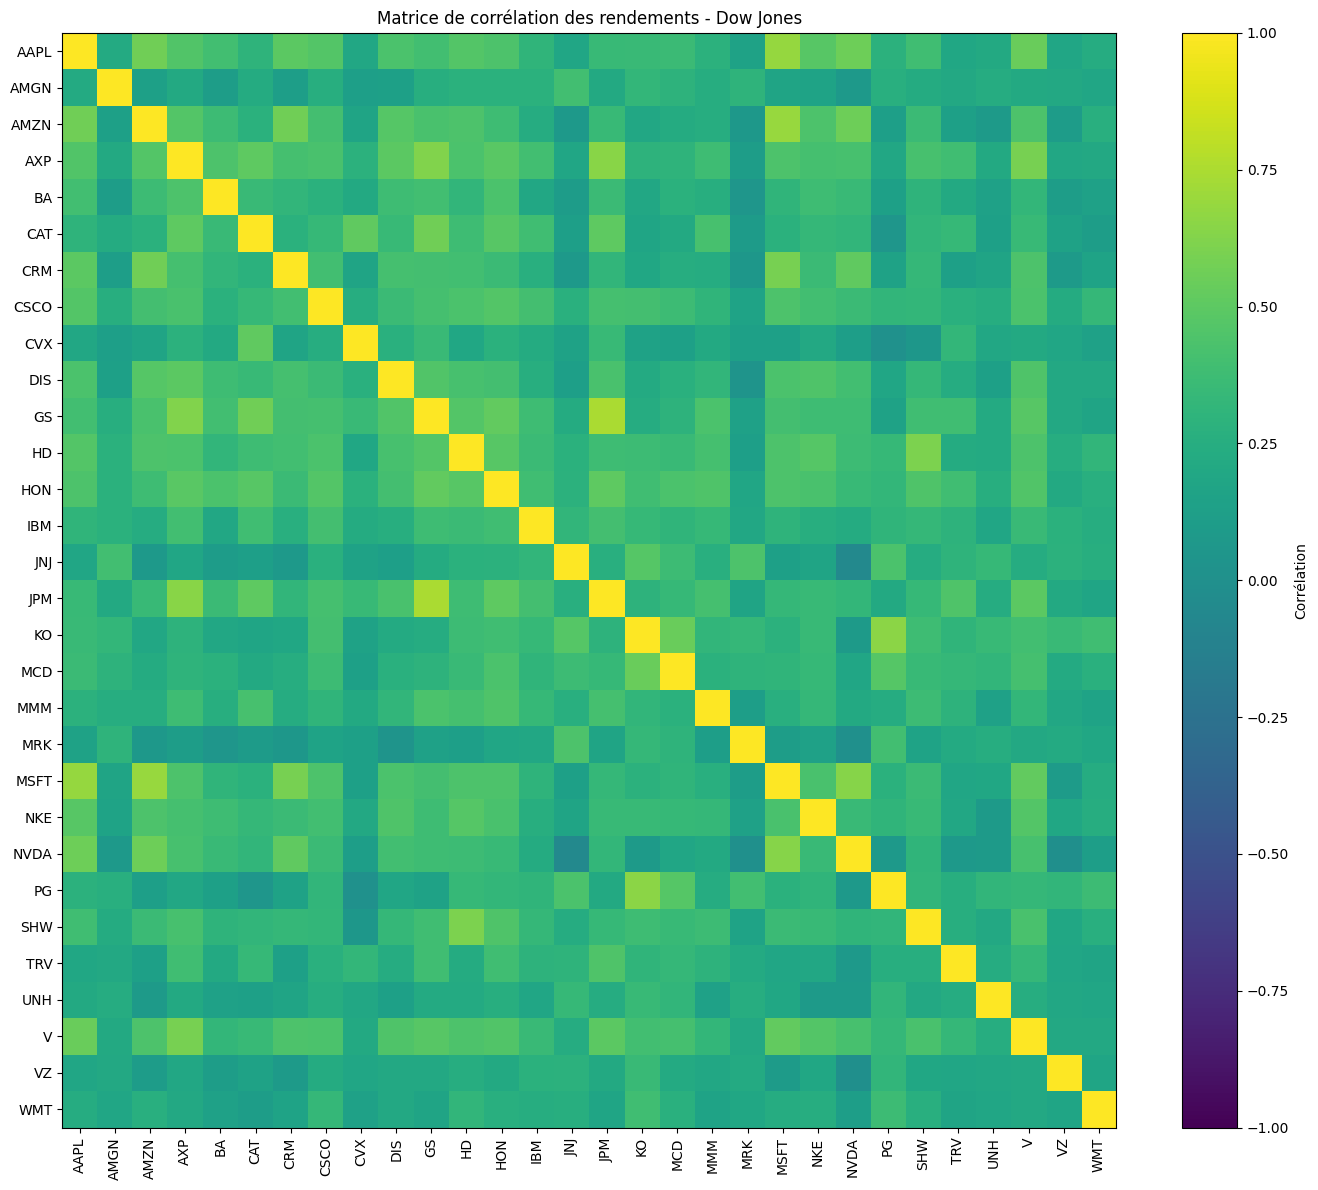

In [9]:
corr_matrix = returns.corr()

plt.figure(figsize=(14, 12))

plt.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Corrélation")

plt.xticks(
    ticks=range(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(corr_matrix.index)),
    labels=corr_matrix.index
)

plt.title("Matrice de corrélation des rendements - Dow Jones")

plt.tight_layout()
plt.show()

In [10]:
pairs_df = find_correlated_pairs(
    cluster_df,
    returns,
    CORR_THRESHOLD
)

print("Les paires les plus corrélées:")
pairs_df

Les paires les plus corrélées:


,Cluster,Stock_A,Stock_B,Correlation
7,5,JPM,GS,0.748825
1,5,AMZN,MSFT,0.689277
6,5,MSFT,AAPL,0.684811
0,1,PG,KO,0.650925
3,5,AXP,JPM,0.640982
5,5,NVDA,MSFT,0.637968
4,5,AXP,GS,0.623757
2,5,SHW,HD,0.602804


## 2.3 Cointégration

In [11]:
cointegration_df = test_cointegration(
    pairs_df,
    prices,
    PVALUE_THRESHOLD
)

cointegration_df


,Cluster,Stock_A,Stock_B,Correlation,PValue,Cointegrated
7,5,SHW,HD,0.602804,0.015643,True
6,5,AXP,GS,0.623757,0.114725,False
4,5,AXP,JPM,0.640982,0.250873,False
3,1,PG,KO,0.650925,0.424274,False
0,5,JPM,GS,0.748825,0.532727,False
5,5,NVDA,MSFT,0.637968,0.555451,False
1,5,AMZN,MSFT,0.689277,0.592113,False
2,5,MSFT,AAPL,0.684811,0.770357,False


## 2.4 Paire retenue pour l'étude

In [12]:
best_pairs = select_best_pairs(
    cointegration_df
)

best_pairs

,Cluster,Stock_A,Stock_B,Correlation,PValue,Cointegrated
7,5,SHW,HD,0.602804,0.015643,True


La seule paire cointégrée sur la période étudiée parmis les paires les plus corrélées est SHW/HD. C'est donc la paire retenue.

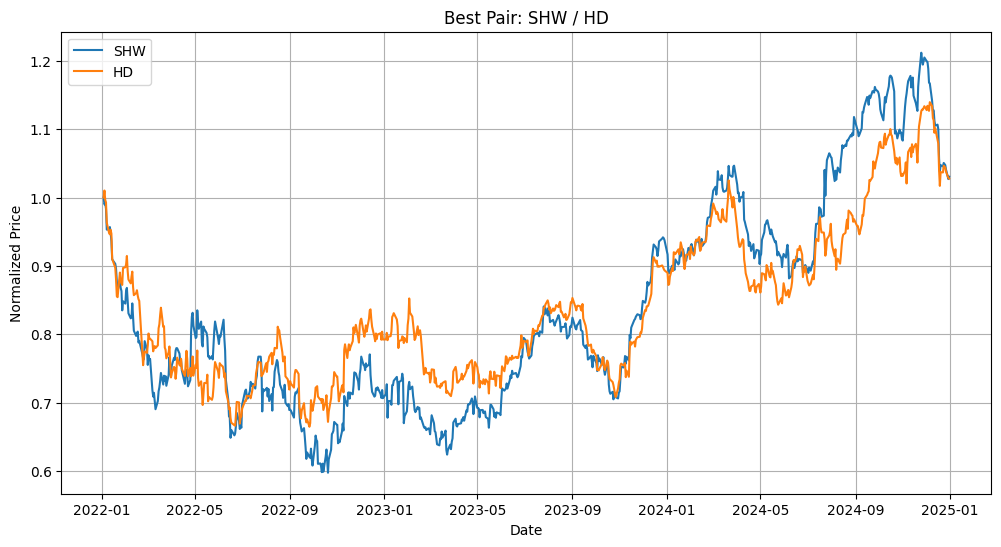

Correlation : 0.6028035909062734
Cointegration p-value : 0.015642627438022687


In [13]:
best_pair = best_pairs.iloc[0]

stock_a = best_pair["Stock_A"]
stock_b = best_pair["Stock_B"]

plot_best_pair(
    prices,
    stock_a,
    stock_b
)

corr = returns[stock_a].corr(
    returns[stock_b]
)

print("Correlation :", corr)

pvalue = best_pair["PValue"]

print("Cointegration p-value :", pvalue)


## 2.5 Etude de la paire choisie sur plusieurs périodes

In [14]:
PERIODS = {
    "2020_2025": ("2020-01-01", "2025-01-01"),
    "2021_2025": ("2021-01-01", "2025-01-01"),
    "2022_2025": ("2022-01-01", "2025-01-01"),
    "2023_2025": ("2023-01-01", "2025-01-01")
}

In [15]:
results = []

for period_name, (start_date, end_date) in PERIODS.items():

    prices_period, returns_period = download_prices(
        TICKERS,
        start_date,
        end_date
    )

    corr = returns_period[stock_a].corr(
        returns_period[stock_b]
    )

    score, pvalue, _ = coint(
        prices_period[stock_a],
        prices_period[stock_b]
    )

    results.append({
        "Period": period_name,
        "Correlation": corr,
        "PValue": pvalue
    })

results_df = pd.DataFrame(results)

results_df

,Period,Correlation,PValue
0,2020_2025,0.686716,0.013625
1,2021_2025,0.599697,0.009342
2,2022_2025,0.602804,0.015643
3,2023_2025,0.581056,0.125424


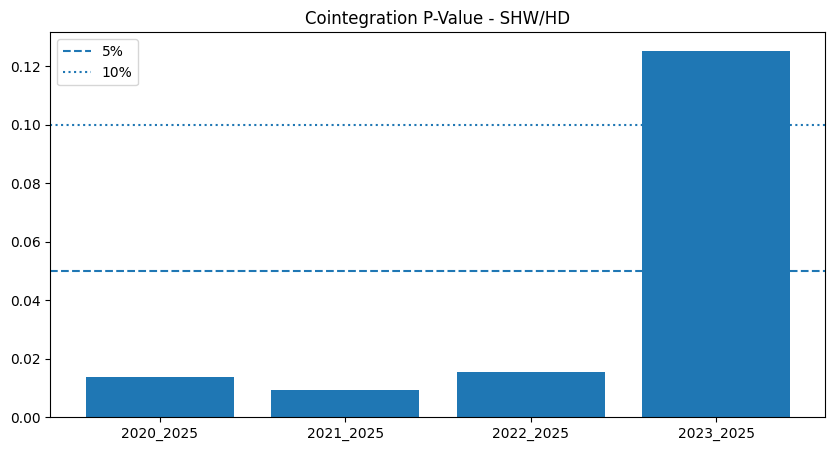

,Period,Correlation,PValue,Cointegrated_5%,Cointegrated_10%
0,2020_2025,0.686716,0.013625,True,True
1,2021_2025,0.599697,0.009342,True,True
2,2022_2025,0.602804,0.015643,True,True
3,2023_2025,0.581056,0.125424,False,False


In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Period"],
    results_df["PValue"]
)

plt.axhline(
    0.05,
    linestyle="--",
    label="5%"
)

plt.axhline(
    0.10,
    linestyle=":",
    label="10%"
)

plt.legend()

plt.title(
    f"Cointegration P-Value - {stock_a}/{stock_b}"
)

plt.show()

results_df["Cointegrated_5%"] = results_df["PValue"] < 0.05
results_df["Cointegrated_10%"] = results_df["PValue"] < 0.10

results_df

#### Interprétation des résultats de cointégration par période

La paire SHW/HD est fortement cointégrée sur les longues périodes
2020–2025, 2021–2025 et 2022–2025.

Cependant, la relation disparaît sur la période récente 2023–2025,
avec une p-value supérieure à 10%.

Cela suggère une rupture structurelle dans la dynamique de la paire,
rendant le pair trading moins robuste

## 2.6 Analyse de stationnarité

In [17]:
stationarity_results = test_spread_stationarity(
    prices=prices,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    alpha=0.05
)

rolling_adf = adf_rolling(
    spread=stationarity_results["Spread"],
    window=252,
    alpha=0.05
)

stationarity_results["Details_DF"]

ANALYSE COMPLÈTE DE STATIONNARITÉ : SHW / HD

[1] Prix en niveau

  ── SHW (niveau)
     ADF  : stat= -1.1576  p=0.6916  (crit 5%=-2.8654)  lags=0
     KPSS : stat=  2.9084  p=0.0100  (crit 5%=0.463)
     → NON-STATIONNAIRE ❌

  ── HD (niveau)
     ADF  : stat= -1.4124  p=0.5763  (crit 5%=-2.8654)  lags=2
     KPSS : stat=  2.6608  p=0.0100  (crit 5%=0.463)
     → NON-STATIONNAIRE ❌

[2] Rendements logarithmiques (1ère différence)

  ── SHW (Δlog)
     ADF  : stat=-27.2661  p=0.0000  (crit 5%=-2.8654)  lags=0
     KPSS : stat=  0.3199  p=0.1000  (crit 5%=0.463)
     → STATIONNAIRE ✅

  ── HD (Δlog)
     ADF  : stat=-20.6414  p=0.0000  (crit 5%=-2.8654)  lags=1
     KPSS : stat=  0.2801  p=0.1000  (crit 5%=0.463)
     → STATIONNAIRE ✅

[3] Estimation du Hedge Ratio (OLS)
  α (constante) : -85.3581
  β (hedge ratio): 1.1616
  R²             : 0.8987

[4] Stationnarité du spread résiduel

  ── Spread SHW-β×HD
     ADF  : stat= -3.7505  p=0.0035  (crit 5%=-2.8654)  lags=3
     KPSS : stat=

,Series,ADF_PValue,KPSS_PValue,Conclusion
0,SHW (niveau),0.6916,0.0100,NON-STATIONNAIRE ❌
1,HD (niveau),0.5763,0.0100,NON-STATIONNAIRE ❌
2,SHW (Δlog),0.0000,0.1000,STATIONNAIRE ✅
3,HD (Δlog),0.0000,0.1000,STATIONNAIRE ✅
4,Spread SHW-β×HD,0.0035,0.0402,"AMBIGU ⚠️ (ADF rejette, KPSS rejette — série ..."


## 2.7 Etude du spread SHW/HD

In [18]:
norm_a = prices["SHW"] / prices["SHW"].iloc[0]
norm_b = prices["HD"] / prices["HD"].iloc[0]

spread = norm_a - norm_b

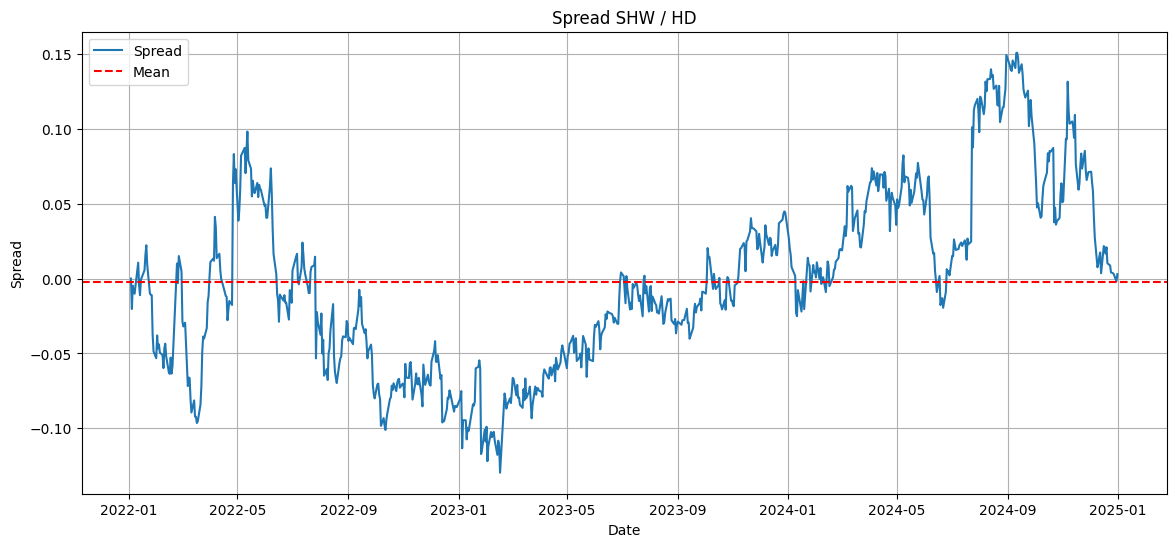

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    spread,
    label="Spread"
)

plt.axhline(
    spread.mean(),
    color="red",
    linestyle="--",
    label="Mean"
)

plt.title(f"Spread {stock_a} / {stock_b}")

plt.xlabel("Date")
plt.ylabel("Spread")

plt.legend()
plt.grid(True)

plt.show()

## 2.8 Etude du Z-score SWH/HD

In [20]:
zscore = (
    spread - spread.mean()
) / spread.std()

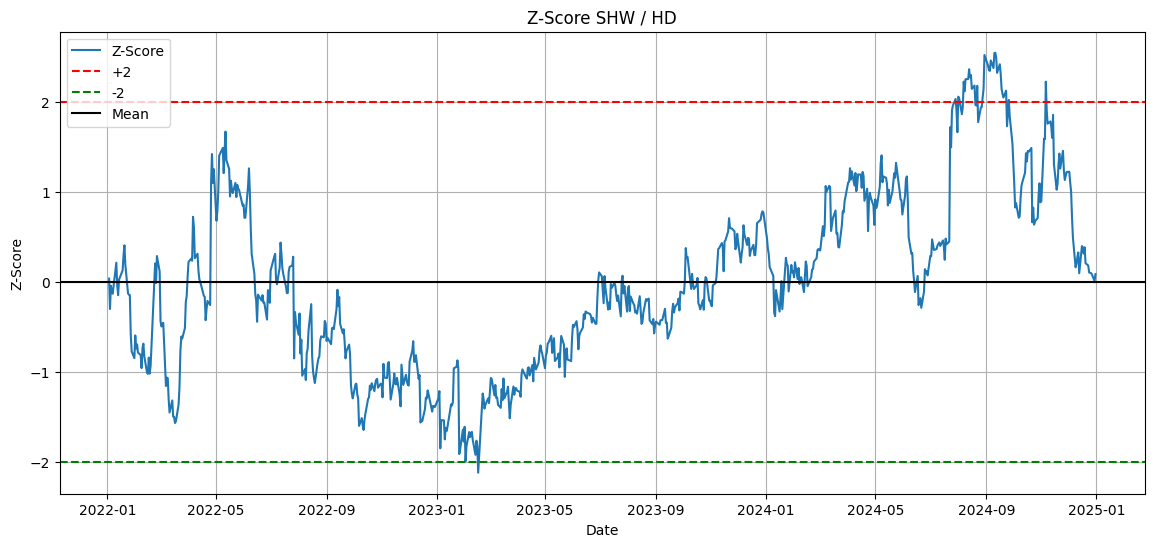

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    zscore,
    label="Z-Score"
)

plt.axhline(
    2,
    color="red",
    linestyle="--",
    label="+2"
)

plt.axhline(
    -2,
    color="green",
    linestyle="--",
    label="-2"
)

plt.axhline(
    0,
    color="black",
    linestyle="-",
    label="Mean"
)

plt.title(f"Z-Score {stock_a} / {stock_b}")

plt.xlabel("Date")
plt.ylabel("Z-Score")

plt.legend()
plt.grid(True)

plt.show()

# 3. Première Stratégie de Pair Trading 

Cette section présente la construction d’une stratégie de pair trading sur la paire SHW / HD.

L’objectif est d’exploiter les écarts temporaires entre deux actions fortement corrélées et cointégrées afin de mettre en place une
stratégie de retour à la moyenne (mean reversion).

## 3.1 Estimation du Hedge Ratio avec régression OLS

In [22]:
signals, beta, ols_model = generate_trading_signals(
    prices=prices,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    entry_threshold=ENTRY_THRESHOLD,
    exit_threshold=EXIT_THRESHOLD
)

print("Hedge Ratio :", beta)

Hedge Ratio : 1.1615865166908932


In [23]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    SHW   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     6664.
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        00:37:23   Log-Likelihood:                -3154.2
No. Observations:                 753   AIC:                             6312.
Df Residuals:                     751   BIC:                             6322.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -85.3581      4.421    -19.309      0.0

## 3.2 Analyse du Spread et du Z-score

Le z-score peut être construit sans régression OLS, par exemple à partir d’un ratio de prix normalisé.

Cependant, la régression OLS permet d’estimer un hedge ratio optimal entre les deux actifs, produisant un spread plus stationnaire et plus adapté au pair trading statistique.

In [24]:
signals[[
    "Spread",
    "Zscore"
]].head()

,Spread,Zscore
Date,,
2022-01-03,-100.807486,-0.967478
2022-01-04,-108.449737,-1.446054
2022-01-05,-102.004968,-1.042467
2022-01-06,-103.138310,-1.113440
2022-01-07,-100.387600,-0.941184


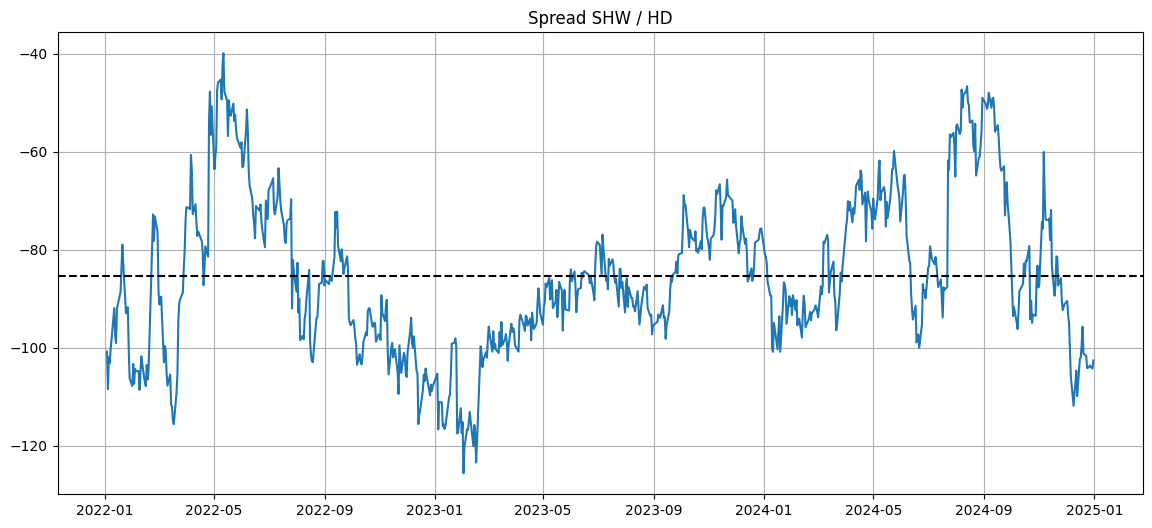

In [25]:
plot_spread(
    signals["Spread"],
    title=f"Spread {STOCK_A} / {STOCK_B}"
)

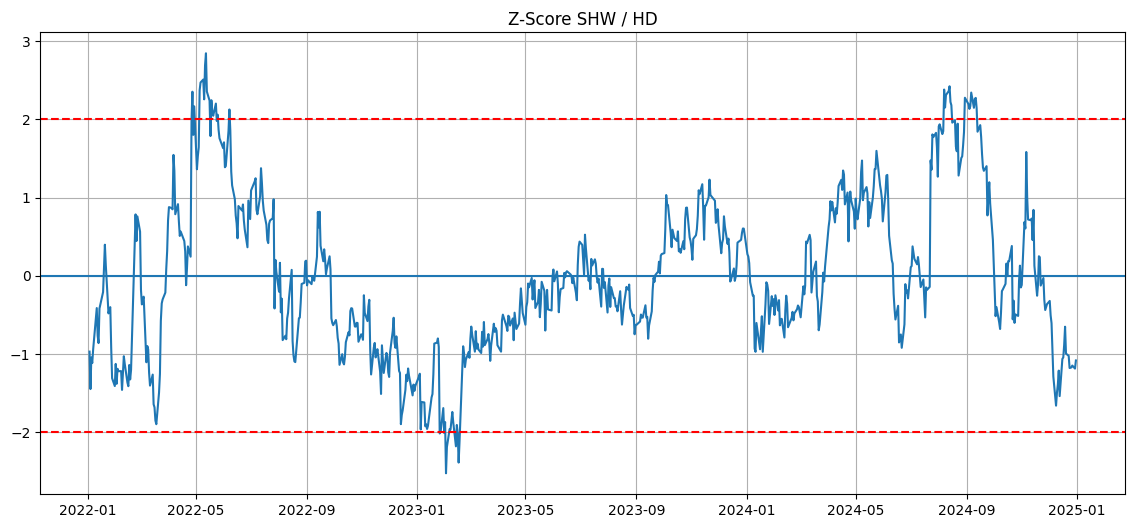

In [26]:
plot_zscore(
    signals["Zscore"],
    entry_threshold=ENTRY_THRESHOLD,
    exit_threshold=EXIT_THRESHOLD,
    title=f"Z-Score {STOCK_A} / {STOCK_B}"
)

## 3.3 Génération des signaux de trading

In [27]:
signals[[
    "Price_A",
    "Price_B",
    "Spread",
    "Zscore",
    "Position_A",
    "Position_B",
    "Signal"
]].tail(20)

,Price_A,Price_B,Spread,Zscore,Position_A,Position_B,Signal
Date,,,,,,,
2024-12-03,389.953949,416.124146,-93.410248,-0.504245,0,0,HOLD
2024-12-04,386.748077,414.738159,-95.006176,-0.604186,0,0,HOLD
2024-12-05,380.010742,413.400696,-100.189932,-0.928805,0,0,HOLD
2024-12-06,379.734528,418.081848,-105.903710,-1.286616,0,0,HOLD
2024-12-09,371.340088,415.959351,-111.832685,-1.657902,0,0,HOLD
2024-12-10,366.555939,409.572296,-109.197718,-1.492894,0,0,HOLD
2024-12-11,366.891296,408.399628,-107.500205,-1.386592,0,0,HOLD
2024-12-12,361.870392,401.654022,-104.685505,-1.210329,0,0,HOLD
2024-12-13,359.552277,404.135162,-109.885679,-1.535976,0,0,HOLD


In [28]:
signals["Signal"].value_counts()

Signal
HOLD                 425
EXIT                 288
SHORT_SHW_LONG_HD     32
LONG_SHW_SHORT_HD      8
Name: count, dtype: int64

## 3.4 Backtest de la stratégie

In [29]:
signals = run_simple_backtest(signals)

signals.tail(20)

,Price_A,Price_B,Spread,Zscore,Position_A,Position_B,Signal,Return_A,Return_B,Strategy_Return,Cumulative_Return
Date,,,,,,,,,,,
2024-12-03,389.953949,416.124146,-93.410248,-0.504245,0,0,HOLD,-0.000657,0.005598,0.0,1.29564
2024-12-04,386.748077,414.738159,-95.006176,-0.604186,0,0,HOLD,-0.008221,-0.003331,-0.0,1.29564
2024-12-05,380.010742,413.400696,-100.189932,-0.928805,0,0,HOLD,-0.017420,-0.003225,-0.0,1.29564
2024-12-06,379.734528,418.081848,-105.903710,-1.286616,0,0,HOLD,-0.000727,0.011324,0.0,1.29564
2024-12-09,371.340088,415.959351,-111.832685,-1.657902,0,0,HOLD,-0.022106,-0.005077,-0.0,1.29564
2024-12-10,366.555939,409.572296,-109.197718,-1.492894,0,0,HOLD,-0.012883,-0.015355,-0.0,1.29564
2024-12-11,366.891296,408.399628,-107.500205,-1.386592,0,0,HOLD,0.000915,-0.002863,0.0,1.29564
2024-12-12,361.870392,401.654022,-104.685505,-1.210329,0,0,HOLD,-0.013685,-0.016517,-0.0,1.29564
2024-12-13,359.552277,404.135162,-109.885679,-1.535976,0,0,HOLD,-0.006406,0.006177,0.0,1.29564


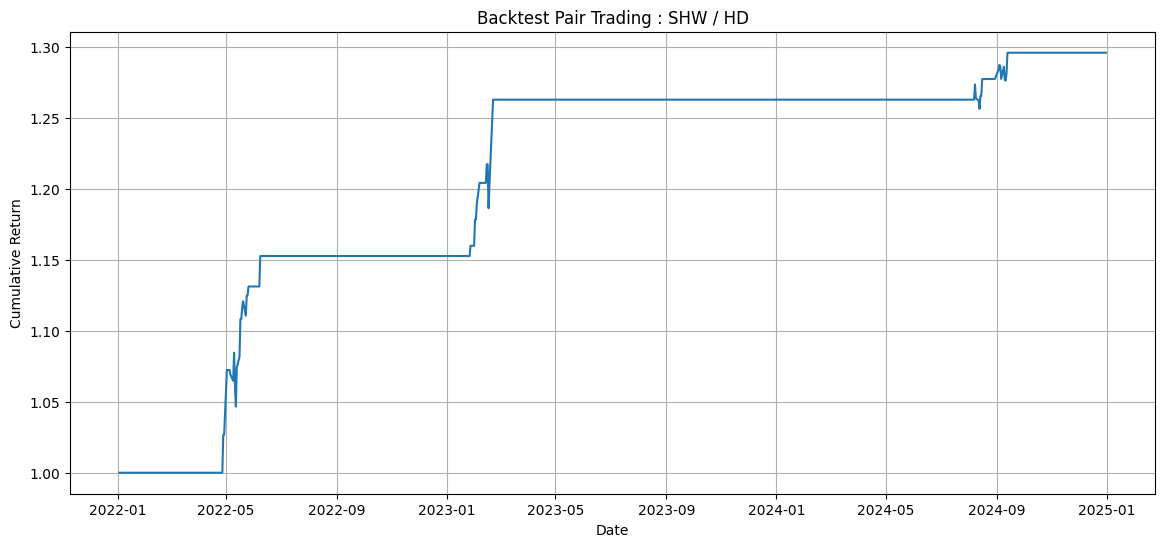

In [30]:
plot_cumulative_return(
    signals,
    title=f"Backtest Pair Trading : {STOCK_A} / {STOCK_B}"
)

In [31]:
metrics = compute_performance_metrics(signals)

print("Total Return :", round(metrics["Total_Return"] * 100, 2), "%")
print("Sharpe Ratio :", round(metrics["Sharpe_Ratio"], 2))
print("Max Drawdown :", round(metrics["Max_Drawdown"] * 100, 2), "%")

metrics_df = pd.DataFrame([metrics])

metrics_df

Total Return : 29.56 %
Sharpe Ratio : 1.51
Max Drawdown : -3.5 %


,Total_Return,Sharpe_Ratio,Max_Drawdown
0,0.29564,1.507818,-0.034995


Le hedge ratio estimé par régression OLS permet de construireun spread stationnaire entre SHW et HD.

Le Z-score mesure les écarts du spread par rapport à sa moyenne :

- Z-score > 2 :
  le spread est considéré trop élevé ;
  stratégie : SHORT SHW / LONG HD.

- Z-score < -2 :
  le spread est considéré trop faible ;
  stratégie : LONG SHW / SHORT HD.

Le backtest permet d’évaluer la capacité de la stratégie à exploiter les phénomènes de retour à la moyenne.

# 4. Coûts de transaction

Dans une stratégie de pair trading, les coûts de transaction jouent un rôle essentiel car la stratégie génère un nombre élevé de trades.

Même si une stratégie semble très rentable avant coûts (« gross return »), les performances réelles peuvent être fortement réduites une fois pris en compte :
- les commissions ;
- le bid-ask spread ;
- le slippage ;
- les coûts d’exécution liés aux positions longues et courtes.

L’objectif de cette analyse est donc de mesurer la robustesse réelle de la stratégie dans des conditions de marché plus réalistes.

In [32]:
cost_model = TransactionCostModel(
    commission_pct=0.001,
    bid_ask_spread=0.0005,
    slippage_pct=0.0005
)

signals_with_costs = apply_costs_to_backtest(
    signals=signals,
    cost_model=cost_model,
    position_col="Position_A",
    return_col="Strategy_Return"
)

sensitivity = cost_sensitivity_analysis(
    signals=signals,
    position_col="Position_A",
    return_col="Strategy_Return"
)

IMPACT DES COÛTS DE TRANSACTION
Modèle utilisé :
  Commission       : 0.100%
  Bid-Ask spread   : 0.050%
  Slippage         : 0.050%
  Coût aller-retour total (4 legs) : 0.800%
Nombre de trades          : 26
Coût total prélevé        : 10.40%
Rendement brut            : 26.41%
Rendement net             : 16.01%

ANALYSE DE SENSIBILITÉ AUX COÛTS DE TRANSACTION
 Cost_Per_Trade_pct  Total_Return_pct  Sharpe_Ratio  Max_Drawdown_pct
               0.00             26.41         1.508             -3.50
               0.05             23.81         1.390             -3.50
               0.10             21.21         1.265             -3.50
               0.20             16.01         0.990             -3.50
               0.30             10.81         0.687             -3.50
               0.50              0.41         0.026             -7.98
               1.00            -25.59        -1.429            -23.00


Dans notre cas :
- la stratégie effectue 26 trades ;
- le coût total prélevé représente plus de 10% de performance ;
- le rendement passe de 26.41% brut à 16.01% net.

L’analyse de sensibilité montre également que :
- de faibles coûts de transaction restent compatibles avec une stratégie profitable ;
- une augmentation importante des coûts détériore rapidement le Sharpe Ratio ;
- à partir de coûts élevés (ex : 1%), la stratégie devient non rentable.

Cette étape est importante car elle permet d’éviter les stratégies artificiellement performantes uniquement en environnement théorique sans friction de marché.

# 5. Optimisation des seuils z-score

Cette section cherche à améliorer la stratégie de pair trading en testant plusieurs combinaisons de seuils d’entrée et de sortie.

L’objectif est d’identifier les paramètres qui maximisent le Sharpe Ratio, tout en contrôlant le drawdown et le nombre de trades.

In [33]:
optimization_df, best_result = optimize_thresholds(
    prices=prices,
    stock_a=STOCK_A,
    stock_b=STOCK_B
)

optimization_df

,Entry_Threshold,Exit_Threshold,Beta,Total_Return,Sharpe_Ratio,Max_Drawdown,Number_of_Trades
2,1.0,0.75,1.161587,0.827756,1.495696,-0.099991,22.5
1,1.0,0.50,1.161587,0.833972,1.426199,-0.114631,16.5
6,1.5,1.00,1.161587,0.461590,1.280983,-0.077152,10.0
0,1.0,0.25,1.161587,0.770633,1.169744,-0.114631,13.5
5,1.5,0.75,1.161587,0.472444,1.166682,-0.099991,9.0
4,1.5,0.50,1.161587,0.504885,1.126302,-0.114631,7.5
3,1.5,0.25,1.161587,0.583457,1.092802,-0.114631,7.5
13,2.5,0.75,1.161587,0.201532,1.038597,-0.042476,2.0
8,2.0,0.50,1.161587,0.304283,1.031796,-0.077152,3.0
12,2.5,0.50,1.161587,0.236184,1.029285,-0.044630,2.0


## 6.1 Selection de la meilleure stratégie

In [34]:
best_signals = best_result["Signals"]

best_entry = best_result["Entry_Threshold"]
best_exit = best_result["Exit_Threshold"]

print("Meilleur seuil d'entrée :", best_entry)
print("Meilleur seuil de sortie :", best_exit)
print("Total Return :", round(best_result["Total_Return"] * 100, 2), "%")
print("Sharpe Ratio :", round(best_result["Sharpe_Ratio"], 2))
print("Max Drawdown :", round(best_result["Max_Drawdown"] * 100, 2), "%")
print("Nombre de trades :", int(best_result["Number_of_Trades"]))

Meilleur seuil d'entrée : 1.0
Meilleur seuil de sortie : 0.75
Total Return : 82.78 %
Sharpe Ratio : 1.5
Max Drawdown : -10.0 %
Nombre de trades : 22


## 6.2 Backtest optimisé

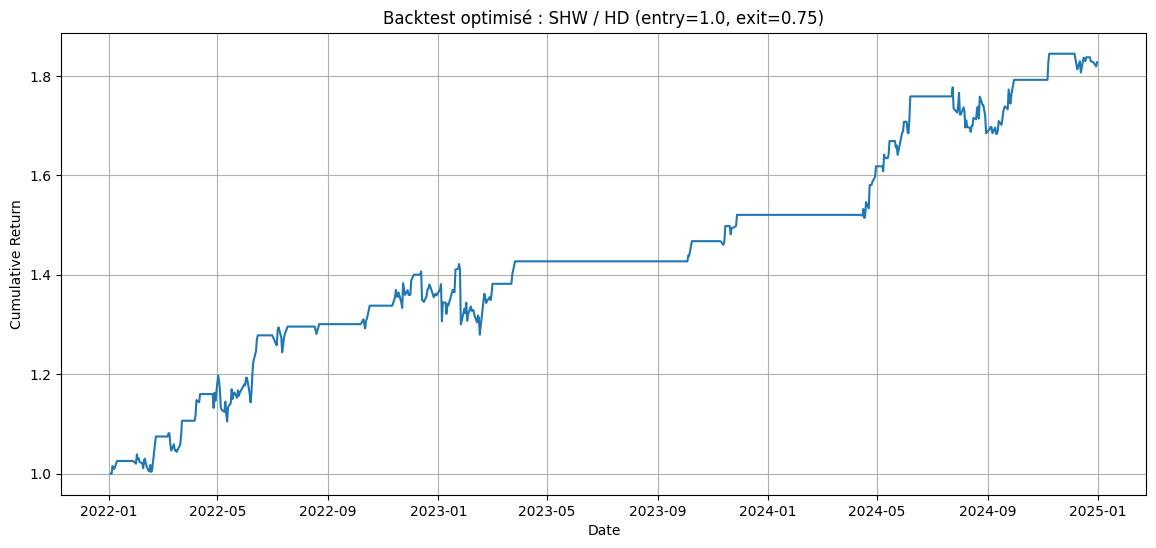

In [35]:
plot_optimized_backtest(
    best_signals=best_signals,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    best_entry=best_entry,
    best_exit=best_exit
)

## 6.3 Z-score avec seuil optimisé

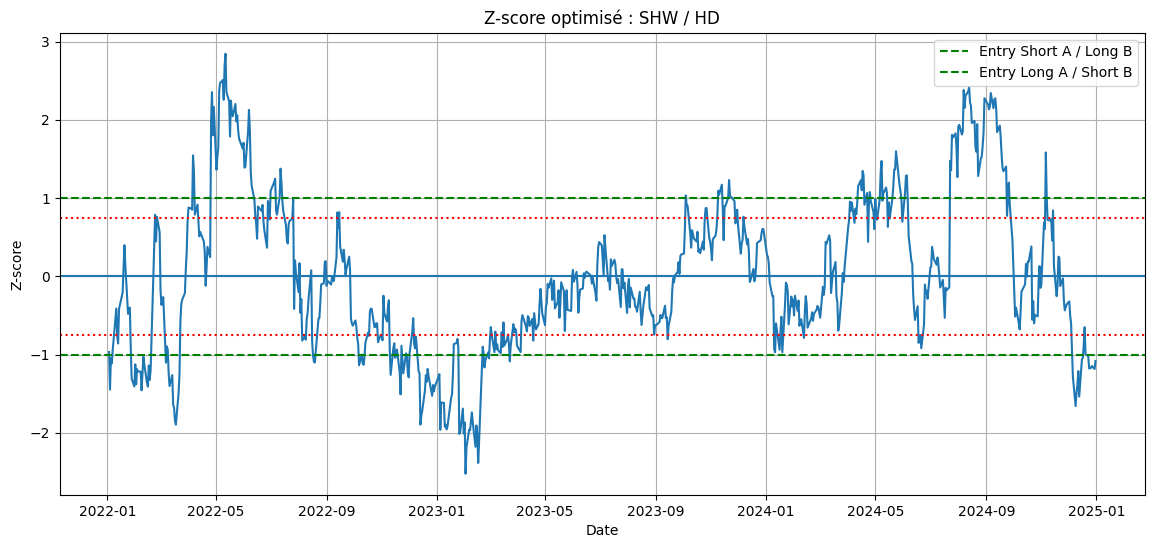

In [36]:
plot_optimized_zscore(
    best_signals=best_signals,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    best_entry=best_entry,
    best_exit=best_exit
)

L’optimisation des seuils permet de comparer plusieurs règles de trading.
Un seuil d’entrée faible augmente le nombre de trades, mais peut générer davantage de faux signaux.
Un seuil d’entrée élevé réduit le nombre de trades, mais sélectionne des écarts plus extrêmes du spread.
Le meilleur couple entry/exit est choisi ici selon le Sharpe Ratio, ce qui permet de privilégier une performance ajustée du risque.

In [37]:
optimization_df.to_csv(
    "outputs/threshold_optimization.csv",
    index=False
)

best_signals.to_csv(
    "outputs/optimized_pair_trading_signals.csv",
    index=True
)

print("Résultats d’optimisation sauvegardés dans outputs.")

Résultats d’optimisation sauvegardés dans outputs.


# 7. Comparaison Pair Trading vs Buy & Hold

Cette section compare la stratégie de pair trading optimisée avec des stratégies passives Buy & Hold.


In [38]:
benchmark_df = build_benchmark_df(
    prices=prices,
    best_signals=best_signals,
    stock_a=STOCK_A,
    stock_b=STOCK_B
)

benchmark_df.head()

,Pair_Trading,Buy_Hold_SHW,Buy_Hold_HD
Date,,,
2022-01-03,1.000000,1.000000,1.000000
2022-01-04,1.000000,0.989974,1.010278
2022-01-05,1.015441,0.991832,0.996574
2022-01-06,1.010709,0.983605,0.992952
2022-01-07,1.009642,0.953114,0.963219


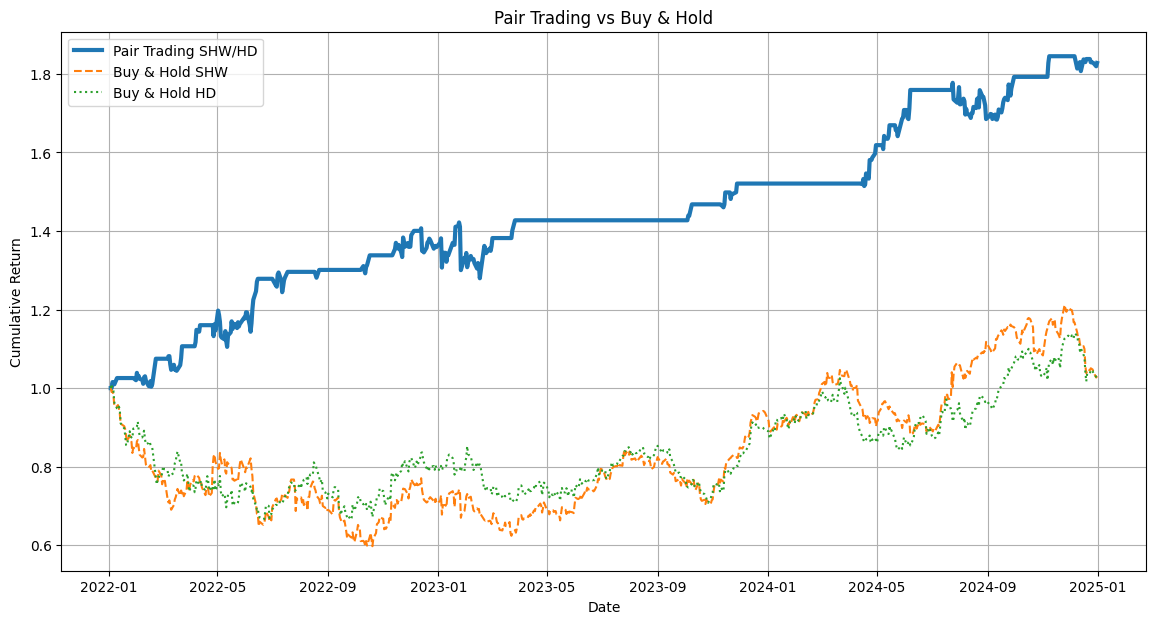

In [39]:
plot_benchmark_comparison(
    benchmark_df=benchmark_df,
    stock_a=STOCK_A,
    stock_b=STOCK_B
)

In [40]:
performance = compute_strategy_performance(
    benchmark_df
)

performance

,Total Return %,Volatility %,Sharpe Ratio,Max Drawdown %
Pair_Trading,82.78,14.18,1.50,-10.00
Buy_Hold_SHW,3.06,27.94,0.18,-40.25
Buy_Hold_HD,2.76,24.90,0.16,-34.20


La comparaison avec les stratégies Buy & Hold permet de vérifier si le pair trading apporte une valeur ajoutée par rapport à une exposition
directionnelle simple aux actions SHW ou HD.

In [41]:
benchmark_df.to_csv(
    "outputs/benchmark_comparison.csv",
    index=True
)


# 8. Prédiction de Convergence 


Cette section applique un modèle de Machine Learning afin de prédire si le spread entre SHW et HD va converger vers sa moyenne le lendemain.

L’objectif est d’améliorer la stratégie de pair trading en utilisant des signaux prédictifs basés sur les caractéristiques du spread.

In [42]:
classifier_result = train_classifier(
    signals
)

classifier_result["ML_DF"].head()


,Price_A,Price_B,Spread,Zscore,Position_A,Position_B,Signal,Return_A,Return_B,Strategy_Return,Cumulative_Return,Zscore_Lag1,Spread_Lag1,Spread_Change,Return_A_Lag1,Return_B_Lag1,Zscore_Next,Target
Date,,,,,,,,,,,,,,,,,,
2022-01-05,322.705597,365.629730,-102.004968,-1.042467,0,0,HOLD,0.001876,-0.013565,0.0,1.0,-1.446054,-108.449737,6.444769,-0.010026,0.010278,-1.113440,0
2022-01-06,320.028778,364.300964,-103.138310,-1.113440,0,0,HOLD,-0.008295,-0.003634,-0.0,1.0,-1.042467,-102.004968,-1.133342,0.001876,-0.013565,-0.941184,1
2022-01-07,310.108276,353.392426,-100.387600,-0.941184,0,0,HOLD,-0.030999,-0.029944,-0.0,1.0,-1.113440,-103.138310,2.750710,-0.008295,-0.003634,-0.534728,1
2022-01-10,310.185028,347.870819,-93.897025,-0.534728,0,0,HOLD,0.000247,-0.015625,0.0,1.0,-0.941184,-100.387600,6.490575,-0.030999,-0.029944,-0.411030,1
2022-01-11,311.336395,347.161499,-91.921721,-0.411030,0,0,EXIT,0.003712,-0.002039,0.0,1.0,-0.534728,-93.897025,1.975304,0.000247,-0.015625,-0.764166,0


In [43]:
print(
    "Accuracy :",
    classifier_result["Accuracy"]
)

Accuracy : 0.5319148936170213


In [44]:
print(
    classifier_result["Classification_Report"]
)

              precision    recall  f1-score   support

           0       0.55      0.28      0.37        93
           1       0.52      0.78      0.63        95

    accuracy                           0.53       188
   macro avg       0.54      0.53      0.50       188
weighted avg       0.54      0.53      0.50       188



In [45]:
feature_importance = classifier_result[
    "Feature_Importance"
]

feature_importance

,Feature,Importance
4,Spread_Change,0.173964
2,Spread,0.168305
0,Zscore,0.161390
3,Spread_Lag1,0.146592
6,Return_B_Lag1,0.126625
1,Zscore_Lag1,0.120439
5,Return_A_Lag1,0.102685


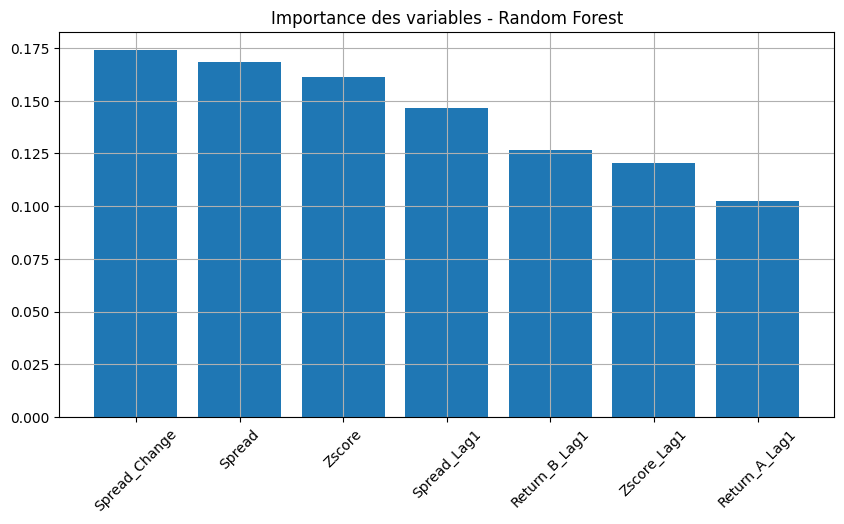

In [46]:
plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Importance des variables - Random Forest")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Le modèle Random Forest cherche à prédire si le spread entre SHW et HD va converger vers sa moyenne.

Les variables les plus importantes représentent :
- le niveau actuel du Z-score ;
- les variations récentes du spread ;
- les rendements récents des deux actions.

Une accuracy supérieure à 50% suggère que le modèle capture partiellement la dynamique de mean reversion.

In [47]:
feature_importance.to_csv(
    "outputs/ml_feature_importance.csv",
    index=False
)

print("Résultats ML sauvegardés dans outputs.")

Résultats ML sauvegardés dans outputs.


# 9. Régression du rendement de la stratégie à J+1 

Cette section ajoute une approche de régression afin de prédire le rendement futur de la stratégie de pair trading.

Contrairement au modèle de classification qui prédit uniquement la convergence du spread, la régression fournit une estimation quantitative du rendement attendu à horizon J+1.

In [48]:
regressor_result = train_regressor(
    signals
)

In [49]:
print(
    "MAE :",
    round(regressor_result["MAE"], 6)
)

print(
    "RMSE :",
    round(regressor_result["RMSE"], 6)
)

print(
    "R2 :",
    round(regressor_result["R2"], 4)
)

MAE : 0.000806
RMSE : 0.003258
R2 : -2.2773


In [50]:
prediction_df = regressor_result[
    "Prediction_DF"
]

prediction_df.head()

,Real_Return_J1,Predicted_Return_J1
Date,,
2024-04-03,-0.0,0.000019
2024-04-04,0.0,0.000019
2024-04-05,0.0,0.000019
2024-04-08,0.0,0.000019
2024-04-09,-0.0,0.000019


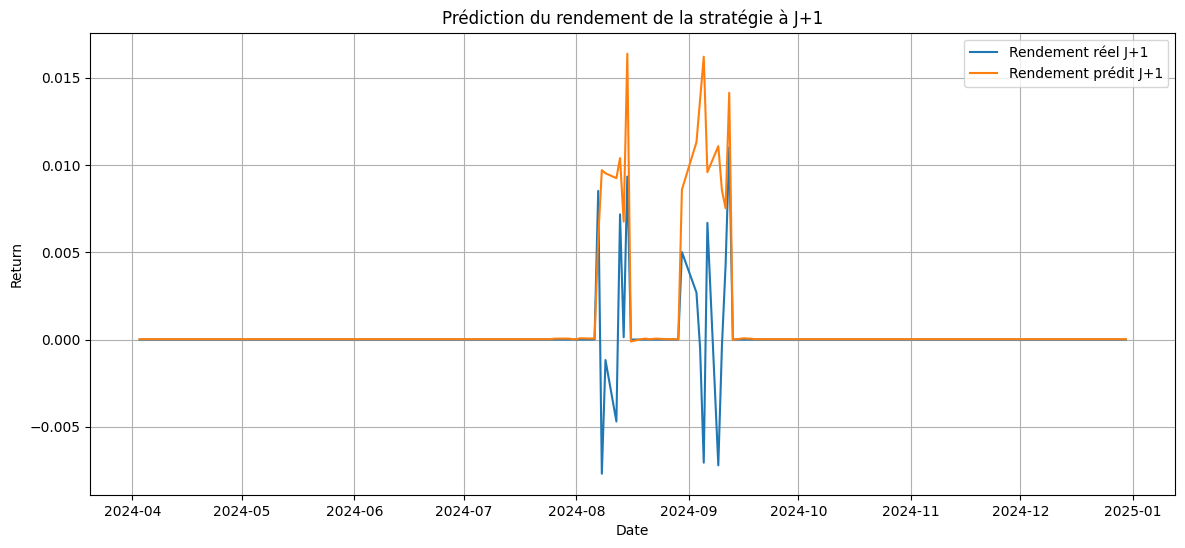

In [51]:
plot_regression_predictions(
    prediction_df
)

Le modèle de régression cherche à prédire le rendement futur de la stratégie de pair trading à horizon J+1.

Les variables utilisées incluent :
- le niveau du Z-score ;
- les variations récentes du spread ;
- les rendements passés des deux actions.

Cette approche permet :
- d’estimer l’intensité potentielle des opportunités ;
- de filtrer les trades peu attractifs ;
- de construire un signal de trading plus fin.

In [52]:
prediction_df.to_csv(
    "outputs/regression_predictions.csv",
    index=True
)

pd.DataFrame([{
    "MAE": regressor_result["MAE"],
    "RMSE": regressor_result["RMSE"],
    "R2": regressor_result["R2"]
}]).to_csv(
    "outputs/regression_metrics.csv",
    index=False
)

print("Résultats de régression sauvegardés.")

Résultats de régression sauvegardés.


## 10. Modèle ML no leakage

In [53]:
from src.ml_no_leakage import (
    train_classifier_no_leakage,
    train_regressor_no_leakage
)

classifier_result_NL = train_classifier_no_leakage(
    signals=signals,
    test_size=0.2,
    n_splits_cv=5
)

regressor_result_NL = train_regressor_no_leakage(
    signals=signals,
    test_size=0.2
)

classifier_result_NL["Feature_Importance"]


CLASSIFIEUR — SPLIT TEMPOREL STRICT
  Vérification anti-leakage : OK ✅
Split temporel :
  Train : 2022-01-18 → 2024-05-28 (593 obs.)
  Test  : 2024-05-29  → 2024-12-30  (149 obs.)


  CV fold 1/5 accuracy : 0.4796
  CV fold 2/5 accuracy : 0.5204
  CV fold 3/5 accuracy : 0.5000
  CV fold 4/5 accuracy : 0.5816
  CV fold 5/5 accuracy : 0.5204
  CV accuracy moyenne : 0.5204 ± 0.0341

Accuracy OOS (hors-échantillon) : 0.5302
Accuracy IN-sample              : 1.0000
  → Un écart important indique du surapprentissage.

Rapport de classification OOS :
              precision    recall  f1-score   support

           0       0.51      0.50      0.51        72
           1       0.54      0.56      0.55        77

    accuracy                           0.53       149
   macro avg       0.53      0.53      0.53       149
weighted avg       0.53      0.53      0.53       149


RÉGRESSEUR — SPLIT TEMPOREL STRICT
  Vérification anti-leakage : OK ✅
Split temporel :
  Train : 2022-01-18 → 2024-05-28 (593 obs.)
  Test  : 2024-05-29  → 2024-12-30  (149 obs.)
MAE  (OOS) : 0.000894
RMSE (OOS) : 0.003070
R²   (OOS) : -1.3091
R²   (IN)  : 0.8301  (si >> R² OOS → surapprentissage)


,Feature,Importance
0,Zscore,0.119966
6,Return_A_MA5,0.115629
8,Zscore_Std10,0.113983
5,Spread_Diff2,0.112298
2,Zscore_Lag2,0.111614
7,Return_B_MA5,0.109792
4,Spread_Diff1,0.109603
3,Zscore_Lag3,0.109350
1,Zscore_Lag1,0.097767


# 11. XGBOOST Classification

Cette section ajoute un modèle XGBoost afin de comparer ses performances avec Random Forest.

XGBoost est un algorithme de gradient boosting largement utilisé en finance quantitative et en Machine Learning tabulaire.

## 11.1 Entrainement du modèle XGBoost

In [54]:
xgb_result = train_xgboost_classifier(
    signals
)

In [55]:
print(
    "XGBoost Accuracy :",
    xgb_result["Accuracy"]
)

XGBoost Accuracy : 0.574468085106383


In [56]:
print(
    xgb_result["Classification_Report"]
)

              precision    recall  f1-score   support

           0       0.59      0.47      0.52        93
           1       0.57      0.67      0.62        95

    accuracy                           0.57       188
   macro avg       0.58      0.57      0.57       188
weighted avg       0.58      0.57      0.57       188



In [57]:
xgb_feature_importance = xgb_result[
    "Feature_Importance"
]

xgb_feature_importance

,Feature,Importance
2,Spread,0.162008
6,Return_B_Lag1,0.152865
3,Spread_Lag1,0.144785
0,Zscore,0.138559
1,Zscore_Lag1,0.137293
4,Spread_Change,0.132685
5,Return_A_Lag1,0.131805


## 11.2 Comparaison Random Forest et XGBoost

In [58]:
comparison_models = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        classifier_result["Accuracy"],
        xgb_result["Accuracy"]
    ]
})

comparison_models

,Model,Accuracy
0,Random Forest,0.531915
1,XGBoost,0.574468


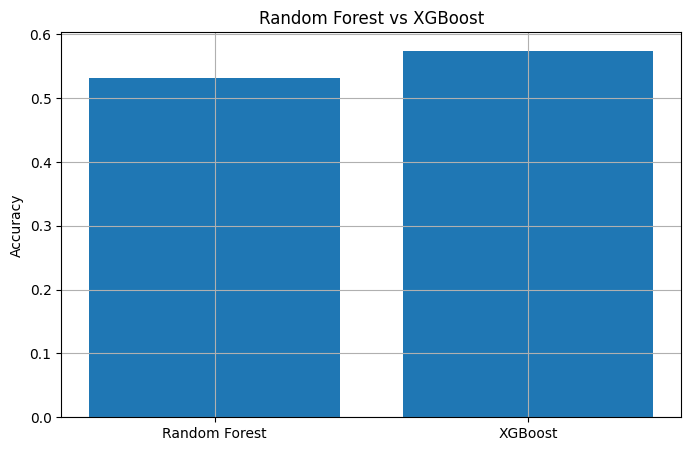

In [59]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_models["Model"],
    comparison_models["Accuracy"]
)

plt.title("Random Forest vs XGBoost")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

XGBoost a été testé comme alternative à Random Forest afin d’évaluer l’impact d’un modèle de gradient boosting sur la prédiction de convergence du spread.

Ce modèle est particulièrement populaire en finance quantitative pour sa capacité à capturer des relations non linéaires complexes sur des données tabulaires.

In [60]:
comparison_models.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

xgb_feature_importance.to_csv(
    "outputs/xgboost_feature_importance.csv",
    index=False
)

# 12. Deep Learning

Cette section ajoute un modèle de deep learning de type LSTM.

Contrairement aux modèles Random Forest ou XGBoost, le LSTM apprend
directement à partir de séquences temporelles. Il utilise les derniers
jours de z-score, spread et rendements pour prédire si le spread va
converger le lendemain.

## 12.1 LSTM CLassification

In [ ]:
lstm_result = train_lstm_classifier(
    signals=signals,
    sequence_length=20,
    test_size=0.2,
    epochs=50,
    batch_size=16
)

In [ ]:
print("LSTM Accuracy:", lstm_result["Accuracy"])
print(lstm_result["Classification_Report"])
print("Latest probability:", lstm_result["Latest_Probability"])

In [ ]:
lstm_result["Prediction_DF"].head()

In [ ]:
plot_lstm_training_history(lstm_result)

In [ ]:
plot_lstm_predictions(lstm_result)

In [ ]:
lstm_result["Prediction_DF"].to_csv(
    "outputs/ml/lstm_predictions.csv",
    index=True
)

## 12.2 LSTM Regression

Cette section utilise un LSTM Regressor pour prédire le rendement futur
de la stratégie à horizon J+1.

Contrairement au RandomForestRegressor, le LSTM apprend à partir de
séquences temporelles de spread, z-score et rendements passés.

In [ ]:
lstm_reg_result = train_lstm_regressor(
    signals=signals,
    sequence_length=5,
    test_size=0.2,
    epochs=10,
    batch_size=64,
    hidden_size=8
)

In [ ]:
print("MAE:", round(lstm_reg_result["MAE"], 6))
print("RMSE:", round(lstm_reg_result["RMSE"], 6))
print("R2:", round(lstm_reg_result["R2"], 4))
print("Latest prediction:", lstm_reg_result["Latest_Prediction"])

In [ ]:
lstm_reg_result["Prediction_DF"].head()

In [ ]:
plot_lstm_regression_predictions(lstm_reg_result)

# 13. Analyse NLP Sentiment

Cette section ajoute un signal textuel simple basé sur les news financières.

L’objectif est d’intégrer une information qualitative dans la stratégie : le sentiment global autour de SHW et HD.

In [61]:
news_data, sentiment_by_stock = compute_sentiment()

print(news_data)
print(sentiment_by_stock)

  Ticker                                              Title  Sentiment_Score
0    SHW  Sherwin-Williams reports strong demand in hous...                2
1     HD  Home Depot faces pressure from weaker consumer...               -3
2    SHW  Sherwin-Williams expands margins despite infla...                1
3     HD              Home Depot announces cautious outlook               -1
  Ticker  Sentiment_Score
0     HD             -2.0
1    SHW              1.5


In [62]:
final_recommendation = build_final_recommendation(
    signals=signals,
    classifier_result_ml=classifier_result,
    sentiment_by_stock=sentiment_by_stock,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    entry_threshold=ENTRY_THRESHOLD
)

final_recommendation

,Stock_A,Stock_B,Latest_Zscore,ML_Prediction_Convergence,Sentiment_A,Sentiment_B,Sentiment_Difference,Final_Recommendation
0,SHW,HD,-1.080408,1,1.5,-2.0,3.5,HOLD


Le signal final combine trois sources d’information :

1. Le signal statistique issu du Z-score du spread.
2. Le signal Machine Learning qui prédit la convergence du spread.
3. Le signal NLP qui mesure le sentiment moyen des news financières.

La recommandation finale est prise uniquement lorsque le signal de pair trading est confirmé par le modèle de Machine Learning.

Le sentiment est conservé comme information complémentaire permettant d’interpréter le contexte économique autour des deux actions.

In [63]:
news_data.to_csv(
    "outputs/news_sentiment.csv",
    index=False
)

sentiment_by_stock.to_csv(
    "outputs/sentiment_by_stock.csv",
    index=False
)

final_recommendation.to_csv(
    "outputs/final_recommendation.csv",
    index=False
)

print("Résultats NLP et recommandation finale sauvegardés.")

Résultats NLP et recommandation finale sauvegardés.


# 14. Machine Learning Filtre

On ajoute ensuite un filtre Machine Learning afin de conserver uniquement les signaux pour lesquels le modèle prédit une probabilité suffisante
de convergence du spread.

In [64]:
ml_filtered_signals = apply_ml_filter(
    signals=best_signals,
    classifier_result=classifier_result,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    entry_threshold=best_entry,
    proba_threshold=0.55
)

ml_filtered_signals[[
    "Zscore",
    "ML_Convergence_Prob",
    "ML_Position_A",
    "ML_Position_B",
    "ML_Signal",
    "ML_Cumulative_Return"
]].tail()

,Zscore,ML_Convergence_Prob,ML_Position_A,ML_Position_B,ML_Signal,ML_Cumulative_Return
Date,,,,,,
2024-12-24,-1.177409,0.522380,0,0,HOLD,2.408682
2024-12-26,-1.169305,0.540537,0,0,HOLD,2.408682
2024-12-27,-1.145692,0.480937,0,0,HOLD,2.408682
2024-12-30,-1.184319,0.510925,0,0,HOLD,2.408682
2024-12-31,-1.080408,NaN,0,0,HOLD,2.408682


## 14.1 Comparaison stratégie brute vs stratégie filtrée par ML

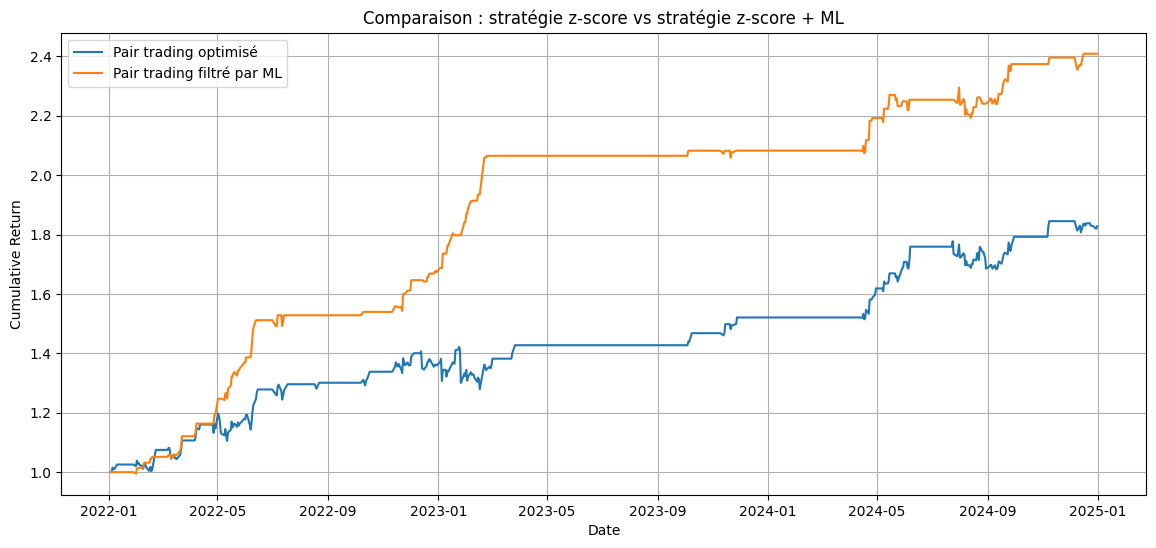

In [65]:
plot_ml_filtered_strategy(
    best_signals=best_signals,
    ml_filtered_signals=ml_filtered_signals
)

## 14.2 Performance de la stratégie filtrée par ML

In [66]:
ml_metrics = compute_ml_filtered_performance(
    ml_filtered_signals
)

print("ML Filtered Total Return :", round(
    ml_metrics["ML_Filtered_Total_Return"] * 100, 2
), "%")

print("ML Filtered Sharpe Ratio :", round(
    ml_metrics["ML_Filtered_Sharpe_Ratio"], 2
))

print("ML Filtered Max Drawdown :", round(
    ml_metrics["ML_Filtered_Max_Drawdown"] * 100, 2
), "%")

pd.DataFrame([ml_metrics])

ML Filtered Total Return : 140.87 %
ML Filtered Sharpe Ratio : 3.22
ML Filtered Max Drawdown : -4.45 %


,ML_Filtered_Total_Return,ML_Filtered_Sharpe_Ratio,ML_Filtered_Max_Drawdown
0,1.408682,3.221929,-0.044473


## 14.3 Comparaison des résultats

In [67]:
summary_results = build_summary_results(
    best_result=best_result,
    ml_metrics=ml_metrics,
    ml_filtered_signals=ml_filtered_signals
)

summary_results

,Strategy,Total Return %,Sharpe Ratio,Max Drawdown %,Number of Trades
0,Pair Trading Optimisé,82.78,1.50,-10.00,22
1,Pair Trading + ML Filter,140.87,3.22,-4.45,61


La stratégie filtrée par Machine Learning est plus sélective : elle ne prend position que lorsque le modèle prédit une probabilité
suffisante de convergence du spread.

Ce filtre peut réduire le nombre de trades et le risque de faux signaux, mais il peut aussi manquer certaines opportunités profitables.

In [68]:
performance.to_csv(
    "outputs/performance_comparison.csv",
    index=True
)

ml_filtered_signals.to_csv(
    "outputs/ml_filtered_signals.csv",
    index=True
)

pd.DataFrame([ml_metrics]).to_csv(
    "outputs/ml_filtered_performance.csv",
    index=False
)

summary_results.to_csv(
    "outputs/final_summary_results.csv",
    index=False
)

print("Tableau final sauvegardé dans outputs.")

print("Résultats benchmark et ML sauvegardés dans outputs/")

Tableau final sauvegardé dans outputs.
Résultats benchmark et ML sauvegardés dans outputs/


# 15. Meta-Model

Cette section construit un méta-modèle chargé de combiner les différents signaux produits dans le pipeline :
- signal de pair trading ;
- probabilité de convergence du classifieur ;
- prédiction de rendement du modèle de régression ;
- sentiment NLP.

Le méta-modèle apprend automatiquement la meilleure combinaison des signaux afin de prédire si le rendement futur de la stratégie
sera positif.

In [69]:
meta_result = train_meta_model(
    signals=signals,
    classifier_result=classifier_result,
    regressor_result=regressor_result,
    sentiment_by_stock=sentiment_by_stock,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    best_entry=best_entry,
    proba_threshold=0.55
)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 15.1 Performance du meta-model

In [70]:
print(
    "Meta-model accuracy :",
    meta_result["Accuracy"]
)

print(
    meta_result["Classification_Report"]
)

Meta-model accuracy : 0.9521276595744681
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       179
           1       0.00      0.00      0.00         9

    accuracy                           0.95       188
   macro avg       0.48      0.50      0.49       188
weighted avg       0.91      0.95      0.93       188



## 15.2 Probabilité finale de rendement positif

In [71]:
print(
    "Probabilité rendement positif :",
    meta_result["Probability_Positive_Return"]
)

print(
    "Recommandation finale :",
    meta_result["Final_Recommendation"]
)

Probabilité rendement positif : 0.011605893640279922
Recommandation finale : HOLD


## 15.3 Tableau final de décision

In [72]:
final_decision_meta, meta_coefficients = build_final_decision_table(
    signals=signals,
    classifier_result=classifier_result,
    regressor_result=regressor_result,
    sentiment_by_stock=sentiment_by_stock,
    meta_result=meta_result,
    stock_a=STOCK_A,
    stock_b=STOCK_B,
    best_entry=best_entry,
    decision_threshold=0.55
)

final_decision_meta

,Metric,Value
0,Latest Zscore,-1.080408
1,Best Entry Threshold,1.0
2,Pair Score,1
3,ML Convergence Probability,0.510925
4,Predicted Strategy Return J+1,0.000019
5,Sentiment SHW,1.5
6,Sentiment HD,-2.0
7,Sentiment Difference,3.5
8,Sentiment Score,1
9,Meta Model Accuracy,0.952128


## 15.4 Coefficients du meta-model

In [73]:
meta_coefficients

,Feature,Coefficient
0,Pair_Score,-0.948220
1,ML_Convergence_Prob,2.563564
2,Reg_Prediction,0.201361
3,Sentiment_Score,-0.006623


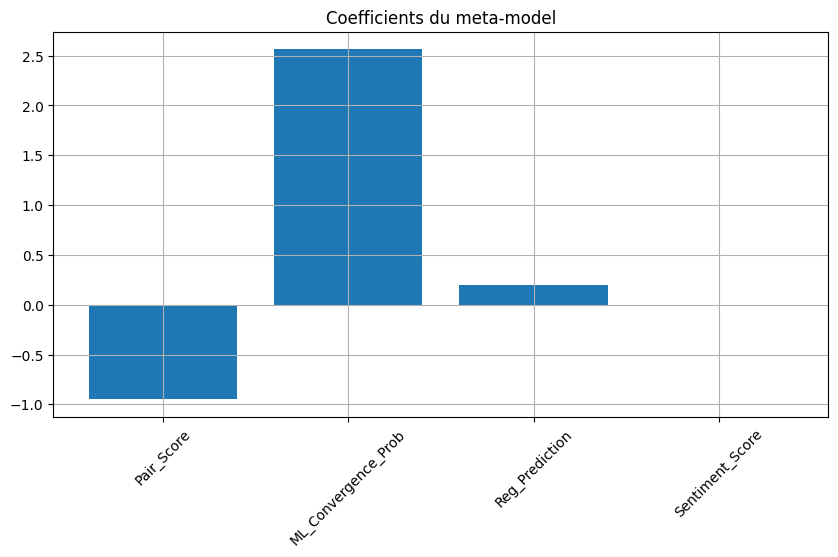

In [74]:
plt.figure(figsize=(10, 5))

plt.bar(
    meta_coefficients["Feature"],
    meta_coefficients["Coefficient"]
)

plt.title("Coefficients du meta-model")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Le meta-model agit comme une couche finale de décision dans le pipeline quantitatif.

Au lieu d’utiliser des poids arbitraires, le modèle apprend
automatiquement l’importance des différents signaux.
Les coefficients estimés permettent d’identifier les variables les plus influentes dans la décision finale.

In [75]:
final_decision_meta.to_csv(
    "outputs/final_decision_meta.csv",
    index=False
)

meta_coefficients.to_csv(
    "outputs/meta_model_coefficients.csv",
    index=False
)

meta_result["Meta_DF"].to_csv(
    "outputs/meta_model_dataset.csv",
    index=True
)

print("Résultats meta-model sauvegardés dans outputs.")

Résultats meta-model sauvegardés dans outputs.
